----
# Word Embeddings
-----

## Notebook Summary

In this notebook, I’ll explore **Word2Vec**, a method used to transform email text into word embeddings. Word embeddings are a numerical representation of words, where words with similar meanings are represented by vectors that are close to each other in the vector space.

This notebook follows a similar layout to the TF-IDF notebook:

1. **Data Loading:** Load the cleaned data from the data folder.

2. **Preparing Text:** Preprocess the text for tokenisation, handling stopwords, and using SpaCy to remove irrelevant words.

3. **Transform Text:** Apply Word2Vec to convert words to embeddings and explore semantic relationships between them.

4. **Topic Modelling with LDA:** Group the data into topics and analyse groupings.


## Set Up
---

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

import re
import string

import spacy
import gensim
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

## Data Loading
----

In [25]:
emails_df = pd.read_csv('../../data/cleaned_emails.csv', index_col= 0)

In [26]:
# working with subset of data first to assess results
email_subset_df = emails_df[:15000].copy()

## Preparing Text
-----

### Combine subject and body

In [27]:
# Combining subject and body to better understand context of emails
email_subset_df['all_text'] = email_subset_df['cleaned_subject'] + ' ' + email_subset_df['cleaned_body']

### Tokenise text using simple_preprocess

In [28]:
nltk.download('stopwords')
eng_stop_words = stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/simybasra/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [29]:
# since punc was removed in cleaning, I need to do the same for stop words
# using regexp to remove all characters which are not words or whitespaces (punctuation)
processed_stop_words = [re.sub(r'[^\w\s]', '', word) for word in eng_stop_words]

In [30]:
# custom list of stop words, all are in lower case since in tokeniser I will force case to be lower
greetings = ['hello', 'hi', 'dear', 'regards', 'thanks', 'thank', 'sincerely', 'best', 'regard', 'regarding']
email_jargon = ['re', 'fw', 'cc','forwarded','forward','original message','original', 'bcc','x', 'subject', 'message', 'email', 'mail','intend','recipient']
html_stop_words = ['html', 'head', 'body', 'id', 'p', 'a', 'div', 'span', 'style', 'src', 'script', 'key', 'h1', 'h2', 'h3', 'h4', 'h5', 'h6', 'click', 'br','svg', 'width', 'height', 'pt', 'link', 'nav', 'title', 'link', 'footer', 'header','td', 'tr', 'font', 'pt', 'img', 'size', 'classtd','th', 'ul', 'ol', 'li', 'meta']
std_phrases= ['also', 'please', 'let', 'know', 'kindly', 'attached', 'find', 'below', 'attach','pm', 'am','like','see','time','us', 'right', 'said']
std_words = ['go', 'get', 'take', 'come', 'think', 'make', 'enron', 'going','look','may','image', 'list', 'would', 'could' ,'fax', 'name', 'one','want','call', 'use','new', 'need', 'meet', 'work','receives', 'receiving','back']
irrelevant_words = [ 'phone', 'long', 'term', 'good', 'web', 'site', 'feel', 'free', 'question', 'questions', 'contact' ,'concern', 'put','together', 'im','sure','last','night', 'soon', 'possible','third','parties','hope', 'well', 'even', 'though','request']

custom_stop_words = greetings + email_jargon + html_stop_words + std_phrases + std_words + irrelevant_words

# adding all custom stop words to existing list 
processed_stop_words.extend(custom_stop_words)

### Removing Employee Names, Dates and Organisations

In [31]:
# load the pre-trained spaCy model for NER
nlp = spacy.load('en_core_web_sm')

def remove_names(text):
    # ensuring all text is of type string
    text = str(text)
    # using model to process email text (subject + body)
    doc = nlp(text)
    # need to reverse order in which entities are removed to avoid disrupting order of text
    #  important as otherwise model will not recognise other entities to be removed
    for e in reversed(doc.ents):
        # to remove words where entity is PERSON, ORG or DATE
        if e.label_ in ("PERSON", "ORG", "DATE",): 
            # remove the entity by slicing the text: 
            #   keep the part before the entity, skip the entity itself and keep the part after it
            text = text[:e.start_char] + text[e.start_char + len(e.text):]

    return text


In [32]:
email_subset_df['all_text'] = email_subset_df['all_text'].apply(remove_names)

## Tokenise Text
-----

In [33]:
tokened_emails = []

In [34]:
# loop througheach email in the dataset
for email in email_subset_df['all_text']:
    # tokenise the email text using simple_preprocess
    tokens = simple_preprocess(email)
    # filter out stopwords
    filtered_tokens = [token for token in tokens if token not in processed_stop_words]
    # Add remaining tokens to tokened_emails
    tokened_emails.append(filtered_tokens)

In [35]:
# sanity check to see all emails have list of tokens
len(tokened_emails)

15000

## Vecotrise Text using Word2Vec
----

In [36]:
# Train the Word2Vec model
lda_model = Word2Vec(
                sentences=tokened_emails,
                vector_size=150,  # size of embeddings, higher values capture more semantics
                window=10,        # setting to 10 to capture more context 
                min_count=5,      # ensure rare words are included 
                workers=4,          
                sg = 1            # choosing to use Skip-Gram
            )

## Most Frequent Words in Emails
----

In [37]:
from wordcloud import WordCloud

In [38]:
word_freq_dict = {}

In [39]:
from collections import Counter

# Tokenize the emails and flatten the list of tokens (you already have tokened_emails)
all_tokens = [token for tokens in tokened_emails for token in tokens]

# Count word frequencies
word_freq = Counter(all_tokens)

for word, freq in word_freq.most_common(20):
    word_freq_dict[word] = freq

In [46]:
for email in email_subset_df['all_text']:
    if 'html' in email:
        print(email)

Why the  owes us all an apology  WHY THE  OWES US ALL AN APOLOGY When recording industry types  tried to get provisions against music swappers included in antiterrorism legislation they trivialized everyone involved in Americas fight against terrorismand proved themselves to be absolutely the sort of people whod do anything for a buck NEWS ANALYSIS  WHATS MS ULTIMATE GOAL FOR XP HINT WAY MORE THAN AN OS When you first try out Windows XP youre reminded no less than fivecount em fivetimes to sign up for its  authentication service These pleas speak of far more than Microsofts persistence Like what Like how it plans to become another  inside an OS PLUS APPLE HINTS AT BREAKTHROUGH DEVICE WHAT COULD IT BE PALM V GETS SOME BLACKBERRY JUICE EXPERT ADVICE CC Holland BANISH YOUR BLANK WALLS WITH HELP FROM THE WEB If you want to decorate your space but are having trouble finding the right posters or prints just turn to your computer  shows you where to find great selections of art online and get

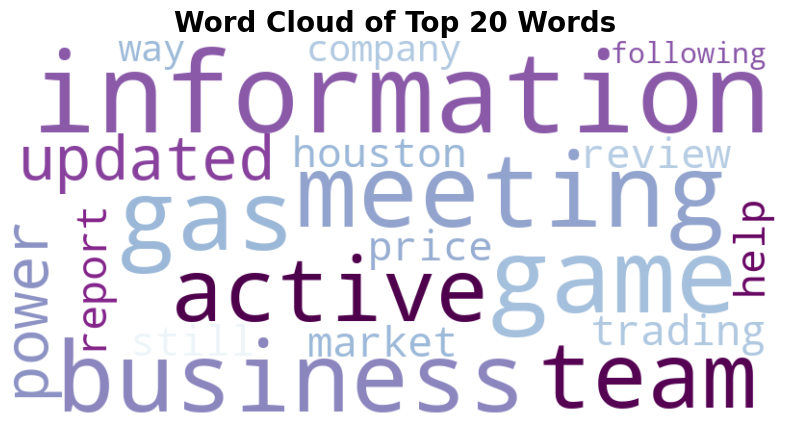

In [41]:
# Create the word cloud
wordcloud = WordCloud(
                width=800,
                height=400,
                background_color='white',
                colormap='BuPu'
            ).generate_from_frequencies(word_freq_dict)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') 
plt.title('Word Cloud of Top 20 Words', fontsize=20, fontweight = 'bold')
plt.show()

----
**Comment:**


## Assess Embedding Relations
-----

In [51]:
# Get the vector for a word
vector = lda_model.wv['following']  # Replace 'word2vec' with any word in your vocabulary

# Find most similar words
similar_words = lda_model.wv.most_similar('following', topn=5)

print("Embedding for '':", vector)
print("Words similar to '':", similar_words[])

Embedding for '': [-0.5592861   0.2662819  -0.05143124  0.16898592 -0.09369733 -0.5963785
 -0.18196039 -0.22322527 -0.0144828   0.3935669   0.26613632 -0.35556796
 -0.29425868  0.45111057 -0.6571283  -0.4055847  -0.08379745 -0.3714399
  0.08748632  0.40099972  0.07864894  0.23606144  0.17654826 -0.02819667
 -0.04299964  0.17429     0.04255996 -0.1435428  -0.34012994 -0.1723105
 -0.11207241  0.23213099 -0.36198628  0.5427299  -0.42653957  0.37012517
  0.53582865 -0.00653438  0.07031787 -0.26727673  0.20722441 -0.07726344
 -0.35845008 -0.4630578   0.37293342 -0.04153633  0.06778471 -0.375712
 -0.0997796   0.37242833 -0.45609218  0.23832196 -0.0547262  -0.07942867
  0.28279856 -0.11820403 -0.07243096  0.26109102  0.04960337 -0.40068212
 -0.24566804 -0.20713435  0.1893822   0.64780235  0.2754363  -0.6776716
 -0.41095045 -0.22929277  0.0720884  -0.18869501  0.48016128 -0.07952527
  0.14830016 -0.03600643  0.01409682  0.02891679  0.5200442   0.31826448
 -0.13766651 -0.17998463  0.1669371  -0

In [43]:
def semantic_rels(word):
    # get the embedding for a word
    embedding = lda_model.wv[word]  
    # find most 5 similar words
    similar_words = lda_model.wv.most_similar(word, topn=5)

    return(f'Words similar to {word}:', similar_words)

In [50]:
semantic_rels('following')

('Words similar to following:',
 [('abovereferenced', 0.5282543301582336),
  ('timesheet', 0.5101954340934753),
  ('identified', 0.5083129405975342),
  ('reconfirm', 0.5065898299217224),
  ('realigned', 0.5035600662231445)])

----
**Comment:**



## Topic Modelling with LDA
---

----
**Comment:**



## Summary
----